In [2]:
!pip install seaborn
!pip install matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp312-cp312-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached contourpy-1.3.1-cp312-cp312-win_amd64.whl (220 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load datasets
app_df = pd.read_csv('Application_Data.csv')
prev_df = pd.read_csv('Previous_application.csv')

# Display first few rows
app_df.head(), prev_df.head()

(   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
 0      100002       1         Cash loans           M            N   
 1      100003       0         Cash loans           F            N   
 2      100004       0    Revolving loans           M            Y   
 3      100006       0         Cash loans           F            N   
 4      100007       0         Cash loans           M            N   
 
   FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
 0               Y             0          202500.0    406597.5      24700.5   
 1               N             0          270000.0   1293502.5      35698.5   
 2               Y             0           67500.0    135000.0       6750.0   
 3               Y             0          135000.0    312682.5      29686.5   
 4               Y             0          121500.0    513000.0      21865.5   
 
    ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
 0  ...               

In [20]:
# Check missing values percentage
app_missing = app_df.isnull().mean() * 100
prev_missing = prev_df.isnull().mean() * 100

print('Application Data Missing Values:')
print(app_missing[app_missing > 0])
print('\nPrevious Application Data Missing Values:')
print(prev_missing[prev_missing > 0])

Application Data Missing Values:
AMT_ANNUITY                    0.002000
AMT_GOODS_PRICE                0.076002
NAME_TYPE_SUITE                0.384008
OWN_CAR_AGE                   65.901318
OCCUPATION_TYPE               31.308626
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.468269
AMT_REQ_CREDIT_BUREAU_WEEK    13.468269
AMT_REQ_CREDIT_BUREAU_MON     13.468269
AMT_REQ_CREDIT_BUREAU_QRT     13.468269
AMT_REQ_CREDIT_BUREAU_YEAR    13.468269
Length: 67, dtype: float64

Previous Application Data Missing Values:
AMT_ANNUITY                  21.184424
AMT_DOWN_PAYMENT             50.397008
AMT_GOODS_PRICE              21.488430
RATE_DOWN_PAYMENT            50.397008
RATE_INTEREST_PRIMARY        99.669993
RATE_INTEREST_PRIVILEGED     99.669993
NAME_TYPE_SUITE              48.486970
CNT_PAYMENT                  21.184424
PRODUCT_COMBINATION           0.016000
DAYS_FIRST_DRAWING           38.320766
DAYS_FIRST_DUE               38.320766
DAYS_LAST_DUE_1ST_VERSION   

C:\Users\mohak\AppData\Local\Temp\ipykernel_23516\118391189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=app_missing.index, y=app_missing.values, palette="viridis")


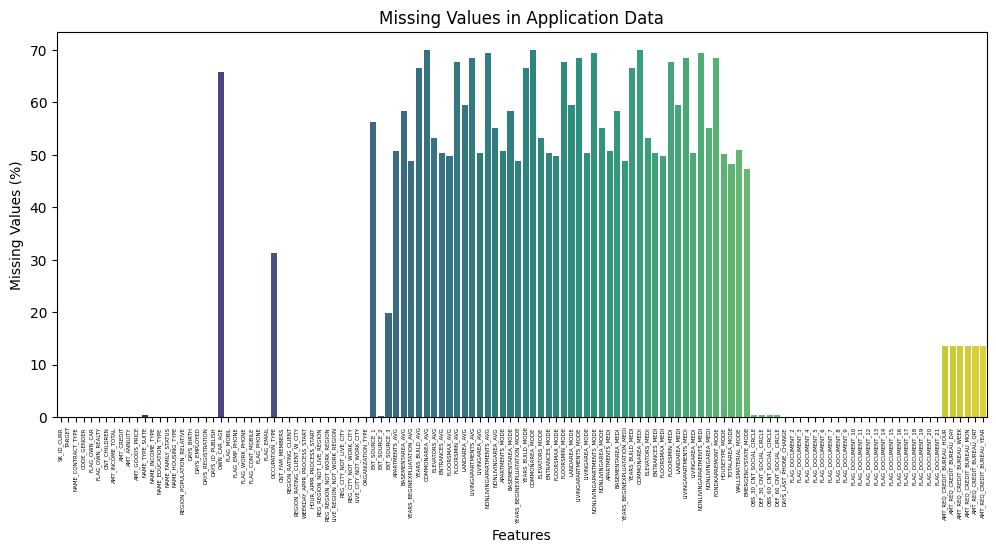

In [26]:
# Plot missing values for Application Data
plt.figure(figsize=(12, 5))
sns.barplot(x=app_missing.index, y=app_missing.values, palette="viridis")
plt.xticks(rotation=90, fontsize=4)
plt.xlabel('Features')
plt.ylabel('Missing Values (%)')
plt.title('Missing Values in Application Data')
plt.show()

C:\Users\mohak\AppData\Local\Temp\ipykernel_23516\1865050860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prev_missing.index, y=prev_missing.values, palette="coolwarm")


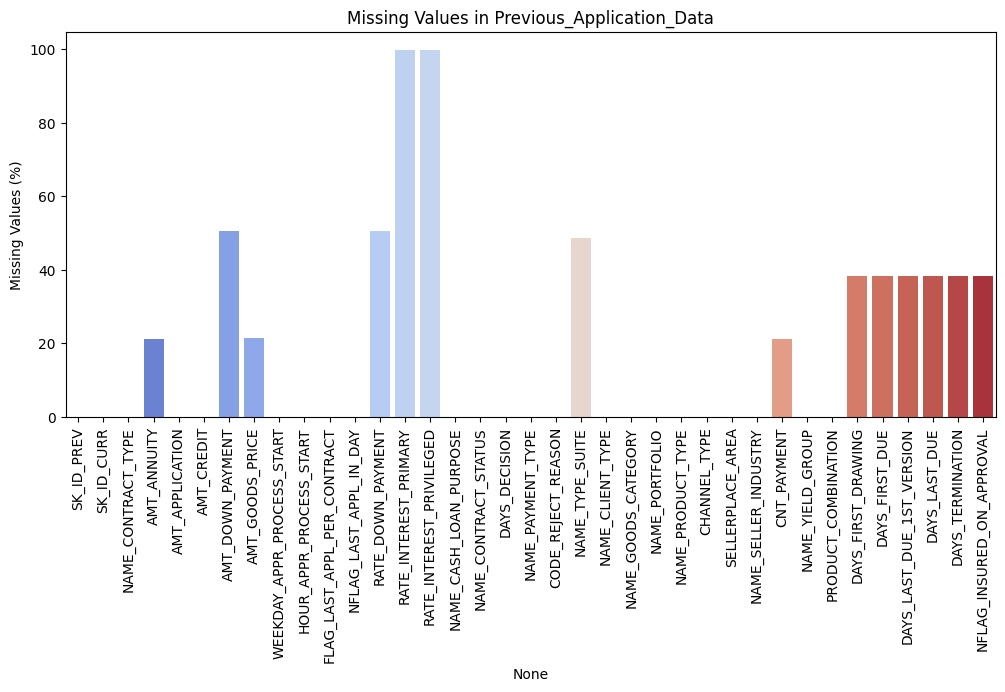

In [27]:
# Plot missing values for Previous Application Data
plt.figure(figsize=(12, 5))
sns.barplot(x=prev_missing.index, y=prev_missing.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.ylabel('Missing Values (%)')
plt.title('Missing Values in Previous_Application_Data')
plt.show()

In [5]:
# Merge datasets on SK_ID_CURR
merged_df = app_df.merge(prev_df, on='SK_ID_CURR', how='left')

# Display merged data info
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50707 entries, 0 to 50706
Columns: 158 entries, SK_ID_CURR to NFLAG_INSURED_ON_APPROVAL
dtypes: float64(84), int64(42), object(32)
memory usage: 61.1+ MB


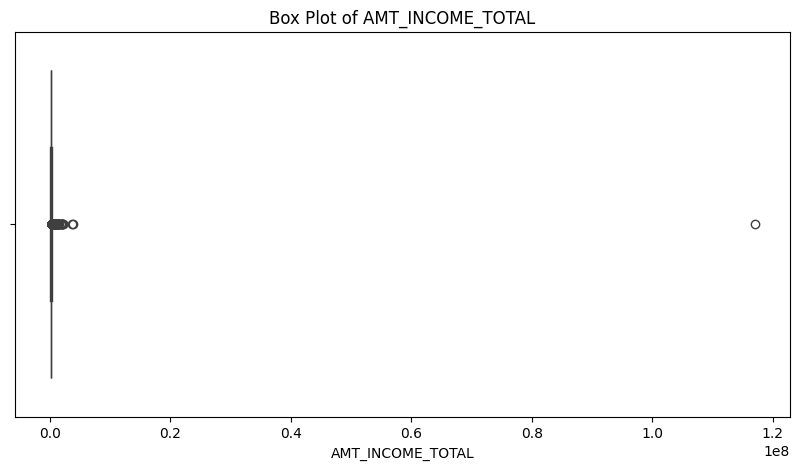

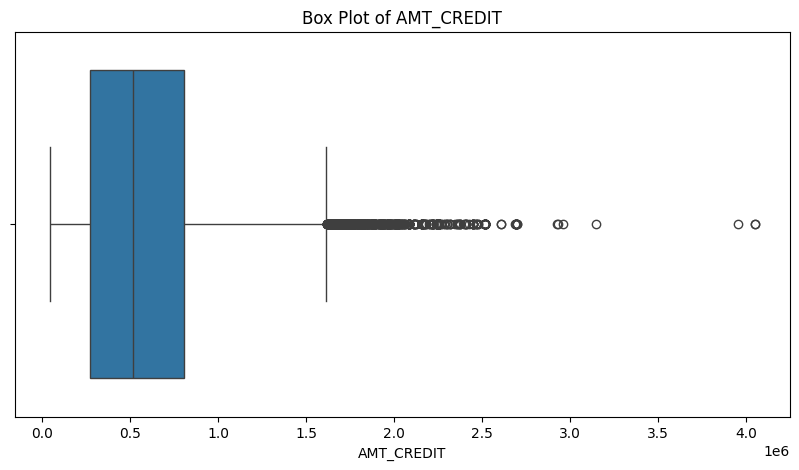

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=app_df['AMT_INCOME_TOTAL'])
plt.title('Box Plot of AMT_INCOME_TOTAL')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=app_df['AMT_CREDIT'])
plt.title('Box Plot of AMT_CREDIT')
plt.show()

C:\Users\mohak\AppData\Local\Temp\ipykernel_23516\4241130299.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=app_df, palette='coolwarm')


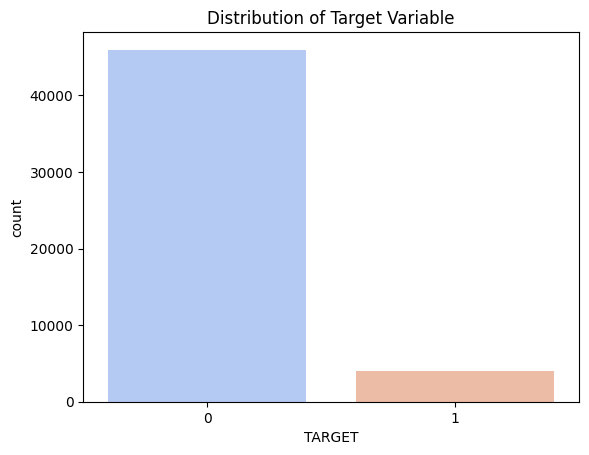

In [6]:
# Visualize target variable distribution
sns.countplot(x='TARGET', data=app_df, palette='coolwarm')
plt.title('Distribution of Target Variable')
plt.show()

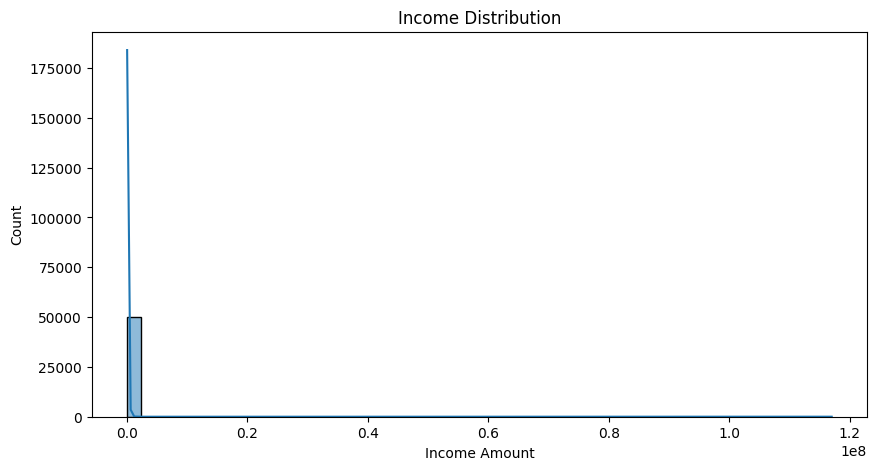

In [7]:
# Income distribution visualization
plt.figure(figsize=(10, 5))
sns.histplot(app_df['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income Amount')
plt.show()

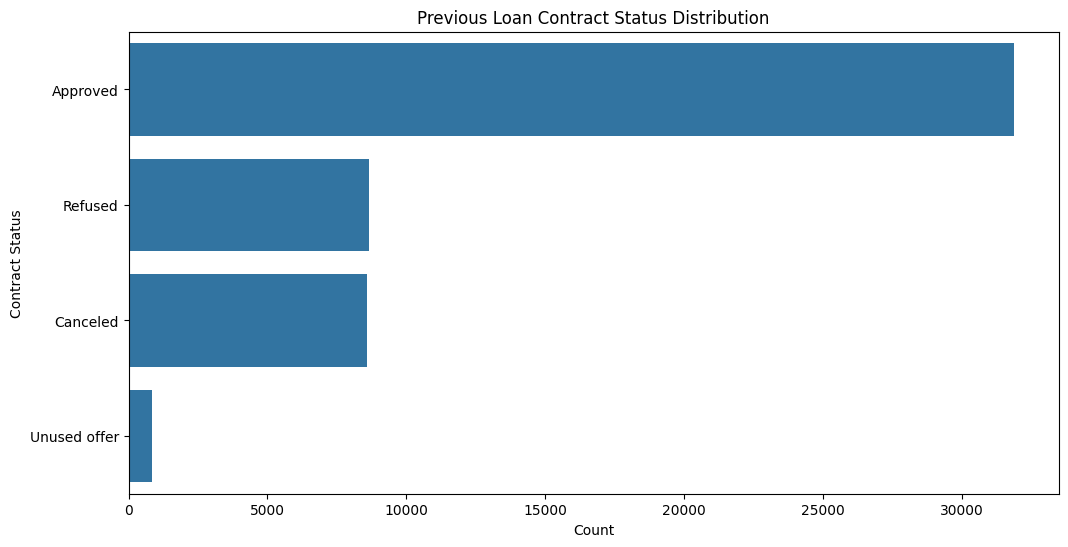

In [8]:
# Visualize previous loan contract status
plt.figure(figsize=(12, 6))
sns.countplot(y='NAME_CONTRACT_STATUS', data=prev_df, order=prev_df['NAME_CONTRACT_STATUS'].value_counts().index)
plt.title('Previous Loan Contract Status Distribution')
plt.xlabel('Count')
plt.ylabel('Contract Status')
plt.show()